In [29]:
import torch
from torch import nn
import numpy as np

In [30]:
from pathlib import Path
data_path = Path("../data/")
image_path = data_path / "desert101"

In [31]:
image_path

PosixPath('../data/desert101')

In [32]:
import os

In [33]:
def check_data(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"# of directories: {len(dirnames)} and {len(filenames)} images in {dirpath}")

In [34]:
check_data(image_path)

# of directories: 2 and 1 images in ../data/desert101
# of directories: 4 and 1 images in ../data/desert101/test
# of directories: 0 and 20 images in ../data/desert101/test/cup_cakes
# of directories: 0 and 20 images in ../data/desert101/test/donuts
# of directories: 0 and 20 images in ../data/desert101/test/cannoli
# of directories: 0 and 20 images in ../data/desert101/test/baklava
# of directories: 4 and 1 images in ../data/desert101/train
# of directories: 0 and 80 images in ../data/desert101/train/cup_cakes
# of directories: 0 and 80 images in ../data/desert101/train/donuts
# of directories: 0 and 80 images in ../data/desert101/train/cannoli
# of directories: 0 and 80 images in ../data/desert101/train/baklava


In [35]:
train_dir = image_path / "train"
test_dir = image_path / "test"

In [36]:
train_dir

PosixPath('../data/desert101/train')

In [37]:
test_dir

PosixPath('../data/desert101/test')

In [38]:
from PIL import Image
import random

In [39]:

image_path_list = list(image_path.glob("*/*/*.jpg"))
random_image = random.choice(image_path_list)
img = Image.open(random_image)

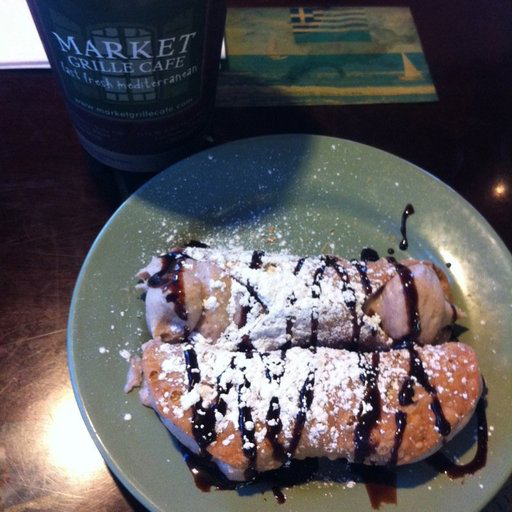

In [40]:
img

In [41]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [43]:
data_transform = transforms.Compose([
    transforms.Resize(size = (64,64)),
    transforms.RandomHorizontalFlip(),
    transforms.TrivialAugmentWide(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), #imagenet standard params
    
])

In [44]:
train_data = datasets.ImageFolder(root=train_dir, transform=data_transform, target_transform=None)
test_data = datasets.ImageFolder(root=test_dir, transform=data_transform, target_transform=None)

In [45]:
train_data

Dataset ImageFolder
    Number of datapoints: 316
    Root location: ../data/desert101/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
               RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
               ColorJitter(brightness=None, contrast=None, saturation=None, hue=None)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [46]:
class_names = train_data.classes

In [47]:
class_names

['baklava', 'cannoli', 'cup_cakes', 'donuts']

In [48]:
len(train_data), len(test_data)

(316, 77)

In [49]:
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

In [50]:
NUM_WORKERS

14

In [51]:
train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, num_workers = NUM_WORKERS, shuffle = True)
test_dataloader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, num_workers = NUM_WORKERS, shuffle = False)

In [52]:
train_dataloader

In [53]:
train_dataloader.dataset[0][0]

tensor([[[-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         ...,
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179]],

        [[-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         ...,
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357]],

        [[-1.8044, -1.8044, -1.8044,  ..., -1.8044, -1.8044, -1.8044],
         [-1.8044, -1.8044, -1.8044,  ..., -1

In [54]:
class DesertClassifier(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__() 

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2)
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 16 * 16, out_features=output_shape)
        )

    def forward(self, x):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))

In [55]:
model_0 = DesertClassifier(
    input_shape=3,
    hidden_units=32,
    output_shape=len(class_names)
)

In [56]:
len(class_names)

4

In [57]:
!pip install torchinfo

In [58]:
from torchinfo import summary

In [59]:
summary(model_0, input_size=[1,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
DesertClassifier                         [1, 4]                    --
├─Sequential: 1-1                        [1, 32, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 32, 64, 64]           896
│    └─ReLU: 2-2                         [1, 32, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 32, 64, 64]           9,248
│    └─ReLU: 2-4                         [1, 32, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 32, 32, 32]           --
├─Sequential: 1-2                        [1, 32, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 32, 32, 32]           9,248
│    └─ReLU: 2-7                         [1, 32, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 32, 32, 32]           9,248
│    └─ReLU: 2-9                         [1, 32, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 32, 16, 16]           --
├─Seq

In [60]:
def train_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer):
    model.train()
    train_loss = 0.0
    train_acc = 0.0

    for batch, (X,y) in enumerate(dataloader):
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_pred, dim = 1), dim = 1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)

    return train_loss, train_acc

In [61]:
def test_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module):

    model.eval()
    test_loss = 0.0
    test_acc = 0.0

    with torch.inference_mode():
        for batch, (X,y) in enumerate(dataloader):
            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            test_pred_labels = test_pred_logits.argmax(dim =1)
            test_acc += (test_pred_labels == y).sum().item() / len(test_pred_labels)
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

In [62]:
def model_train(model: torch.nn.Module, 
                train_dataloader: torch.utils.data.DataLoader,
                test_dataloader: torch.utils.data.DataLoader,
                optimizer: torch.optim.Optimizer,
                loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),               
                epochs: int = 10):
    results = {
        "train_loss" : [],
        "train_acc": [],
        "test_loss": [],
        "test_acc":[]
    }
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model= model, dataloader = train_dataloader, loss_fn=loss_fn, optimizer=optimizer)
        test_loss, test_acc = test_step(model= model, dataloader = test_dataloader, loss_fn=loss_fn)

        print(f"Epoch: {epoch}, Train Acc: {train_acc}, Train Loss: {train_loss}, Test Acc: {test_acc}, Test Loss{test_loss}")
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)
    return results

In [63]:
EPOCHS = 10
model_0  = DesertClassifier(input_shape=3,
                           hidden_units=32,
                            output_shape=len(class_names)
                           )
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(params=model_0.parameters(), lr = 0.001)

model_0_results = model_train(model = model_0, train_dataloader=train_dataloader, test_dataloader=test_dataloader,
                             loss_fn=loss_fn, optimizer= optimizer, epochs = EPOCHS)

Epoch: 0, Train Acc: 0.21517857142857144, Train Loss: 1.4008849620819093, Test Acc: 0.23397435897435895, Test Loss1.3779255946477253
Epoch: 1, Train Acc: 0.3053571428571428, Train Loss: 1.3686071753501892, Test Acc: 0.3229166666666667, Test Loss1.3522233565648396
Epoch: 2, Train Acc: 0.346875, Train Loss: 1.3490617513656615, Test Acc: 0.28125, Test Loss1.366717020670573
Epoch: 3, Train Acc: 0.3607142857142857, Train Loss: 1.3079188942909241, Test Acc: 0.4198717948717949, Test Loss1.2712968190511067
Epoch: 4, Train Acc: 0.39285714285714285, Train Loss: 1.2693685650825501, Test Acc: 0.4094551282051282, Test Loss1.3003616333007812
Epoch: 5, Train Acc: 0.4486607142857143, Train Loss: 1.219863522052765, Test Acc: 0.375, Test Loss1.3857836723327637
Epoch: 6, Train Acc: 0.4397321428571429, Train Loss: 1.2230427265167236, Test Acc: 0.4150641025641026, Test Loss1.194228728612264
Epoch: 7, Train Acc: 0.43616071428571435, Train Loss: 1.2230700612068177, Test Acc: 0.3541666666666667, Test Loss1.29

In [64]:
import matplotlib.pyplot as plt

In [65]:
def plot_loss_curves(results):
    loss = results["train_loss"]
    test_loss = results["test_loss"]
    acc = results["train_acc"]
    test_acc = results["test_acc"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize = (16,8))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label = "Train Loss")
    plt.plot(epochs, test_loss, label = "Test Loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label = "Train Accuracy")
    plt.plot(epochs, test_acc, label = "Test Accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()
    plt.tight_layout()
    plt.show()

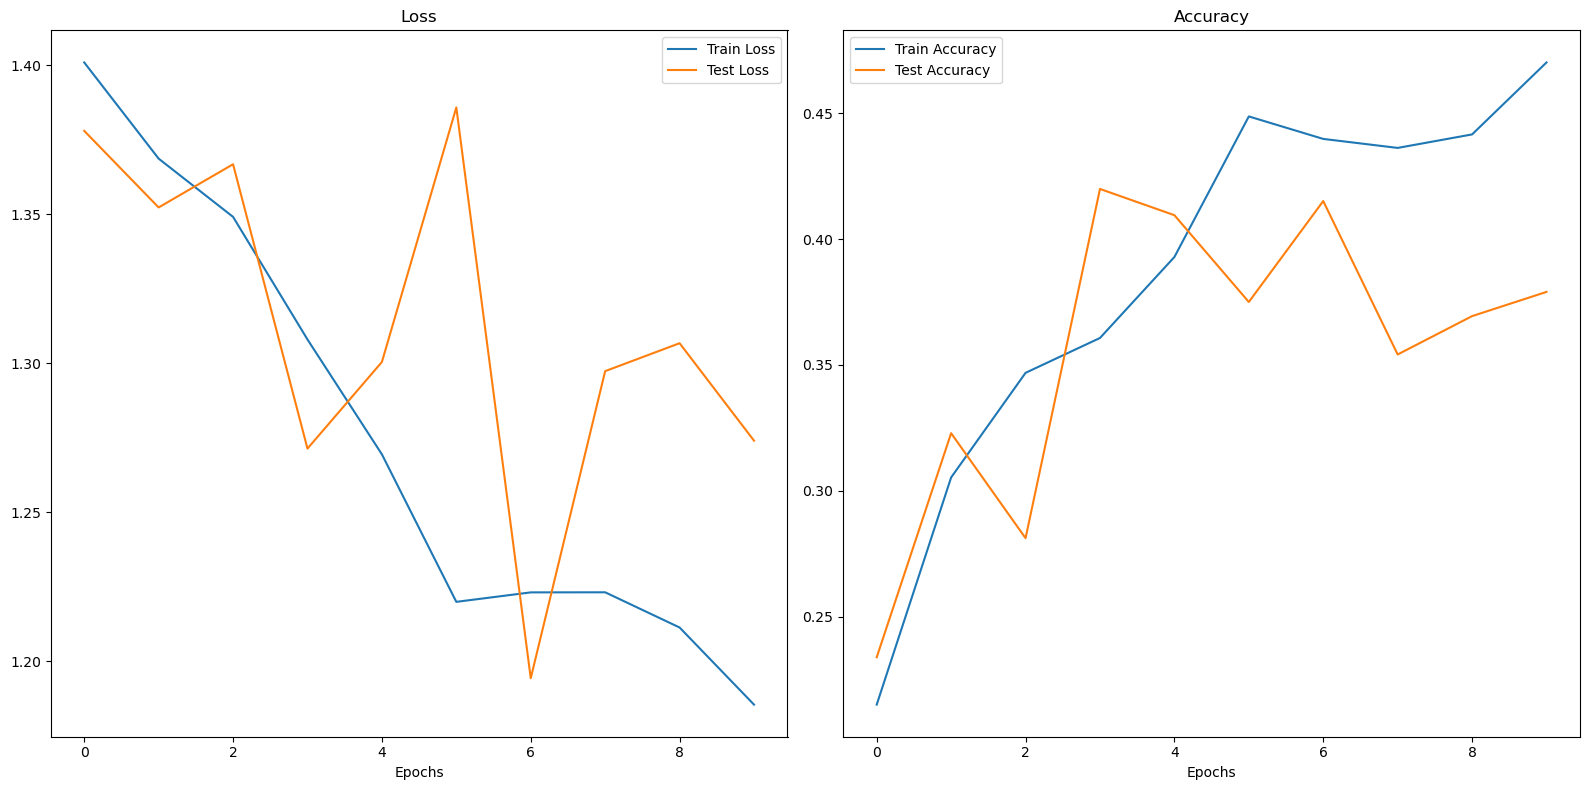

In [66]:
plot_loss_curves(model_0_results)

In [67]:
online_image_path = data_path / "baklava.jpg"

In [68]:
online_image_path

PosixPath('../data/baklava.jpg')

In [69]:
import torchvision

In [70]:
single_image = torchvision.io.read_image(str(online_image_path))

In [71]:
single_image

tensor([[[207, 206, 207,  ..., 205, 205, 205],
         [204, 204, 200,  ..., 206, 206, 205],
         [210, 206, 206,  ..., 206, 207, 206],
         ...,
         [205, 203, 204,  ..., 181, 183, 202],
         [203, 211, 204,  ..., 187, 188, 207],
         [203, 211, 205,  ..., 189, 190, 208]],

        [[203, 202, 203,  ..., 201, 201, 201],
         [200, 200, 196,  ..., 202, 202, 201],
         [206, 202, 202,  ..., 202, 203, 202],
         ...,
         [203, 201, 202,  ..., 174, 178, 197],
         [202, 209, 202,  ..., 180, 183, 202],
         [202, 210, 204,  ..., 182, 185, 203]],

        [[200, 199, 200,  ..., 198, 198, 198],
         [197, 197, 193,  ..., 199, 199, 198],
         [203, 199, 199,  ..., 199, 200, 199],
         ...,
         [208, 206, 207,  ..., 181, 184, 203],
         [207, 214, 207,  ..., 187, 189, 208],
         [207, 215, 209,  ..., 189, 191, 209]]], dtype=torch.uint8)

In [72]:
single_image = torchvision.io.read_image(str(online_image_path)).type(torch.float32)

In [73]:
single_image

tensor([[[207., 206., 207.,  ..., 205., 205., 205.],
         [204., 204., 200.,  ..., 206., 206., 205.],
         [210., 206., 206.,  ..., 206., 207., 206.],
         ...,
         [205., 203., 204.,  ..., 181., 183., 202.],
         [203., 211., 204.,  ..., 187., 188., 207.],
         [203., 211., 205.,  ..., 189., 190., 208.]],

        [[203., 202., 203.,  ..., 201., 201., 201.],
         [200., 200., 196.,  ..., 202., 202., 201.],
         [206., 202., 202.,  ..., 202., 203., 202.],
         ...,
         [203., 201., 202.,  ..., 174., 178., 197.],
         [202., 209., 202.,  ..., 180., 183., 202.],
         [202., 210., 204.,  ..., 182., 185., 203.]],

        [[200., 199., 200.,  ..., 198., 198., 198.],
         [197., 197., 193.,  ..., 199., 199., 198.],
         [203., 199., 199.,  ..., 199., 200., 199.],
         ...,
         [208., 206., 207.,  ..., 181., 184., 203.],
         [207., 214., 207.,  ..., 187., 189., 208.],
         [207., 215., 209.,  ..., 189., 191., 209.]]]

In [74]:
single_image = single_image / 255

In [75]:
single_image

tensor([[[0.8118, 0.8078, 0.8118,  ..., 0.8039, 0.8039, 0.8039],
         [0.8000, 0.8000, 0.7843,  ..., 0.8078, 0.8078, 0.8039],
         [0.8235, 0.8078, 0.8078,  ..., 0.8078, 0.8118, 0.8078],
         ...,
         [0.8039, 0.7961, 0.8000,  ..., 0.7098, 0.7176, 0.7922],
         [0.7961, 0.8275, 0.8000,  ..., 0.7333, 0.7373, 0.8118],
         [0.7961, 0.8275, 0.8039,  ..., 0.7412, 0.7451, 0.8157]],

        [[0.7961, 0.7922, 0.7961,  ..., 0.7882, 0.7882, 0.7882],
         [0.7843, 0.7843, 0.7686,  ..., 0.7922, 0.7922, 0.7882],
         [0.8078, 0.7922, 0.7922,  ..., 0.7922, 0.7961, 0.7922],
         ...,
         [0.7961, 0.7882, 0.7922,  ..., 0.6824, 0.6980, 0.7725],
         [0.7922, 0.8196, 0.7922,  ..., 0.7059, 0.7176, 0.7922],
         [0.7922, 0.8235, 0.8000,  ..., 0.7137, 0.7255, 0.7961]],

        [[0.7843, 0.7804, 0.7843,  ..., 0.7765, 0.7765, 0.7765],
         [0.7725, 0.7725, 0.7569,  ..., 0.7804, 0.7804, 0.7765],
         [0.7961, 0.7804, 0.7804,  ..., 0.7804, 0.7843, 0.

Text(0.5, 1.0, 'torch.Size([3, 1500, 1500])')

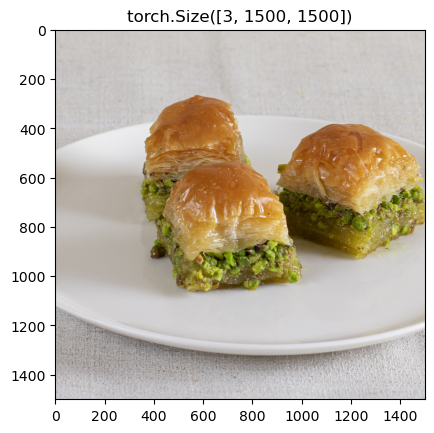

In [76]:
plt.imshow(single_image.permute(1,2,0))
plt.title(single_image.shape)

In [77]:
single_image_transform = transforms.Compose(
    [
        transforms.Resize(size = (64,64))
    ]
)

single_image = single_image_transform(single_image)

Text(0.5, 1.0, 'torch.Size([3, 64, 64])')

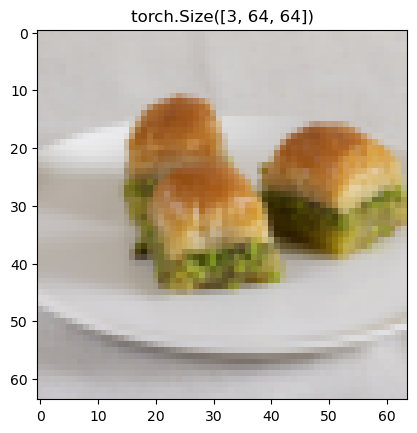

In [78]:
plt.imshow(single_image.permute(1,2,0))
plt.title(single_image.shape)

In [79]:
single_image = single_image.unsqueeze(dim=0)

In [80]:
model_0.eval()
with torch.inference_mode():
    logits = model_0(single_image)
    probs = torch.softmax(logits, dim = 1)
    pred_idx = probs.argmax(dim = 1).item()
print("Predicted Class: ", class_names[pred_idx])

Predicted Class:  cannoli
